一、核心库导入

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from math import sqrt
from numpy import concatenate
from pandas import read_csv, DataFrame, concat
from datetime import datetime
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import keras.backend as K
from keras.layers import Multiply
from keras.models import Sequential ,Model
from keras.layers import Dense , Input , Reshape , Flatten ,Permute , Lambda , RepeatVector ,Conv1D , MaxPooling1D , Dropout, Bidirectional, Activation
from keras.layers import GRU, LSTM
from keras.utils.vis_utils import plot_model
from keras.optimizers import SGD,Adam
from keras.utils import np_utils   #np_utils
from keras.callbacks import TensorBoard  #TensorBoard可视化

二、数据集读取与预处理模块

1. 读取数据集

In [2]:
# T:0
# H:1
# Surge:2
# Heave:4
# Force1:8
# 四级海况（波高2周期11.2水深50)
data_1 = pd.read_csv('15.6周期.csv')
data_1.head()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
0,0.1,-919.0,-0.0632,-9.720000e-07,-72.2,-2.440000e-09,0.000002,-3.610000e-09,4920.0,4920.0
1,0.2,-800.0,-1.2800,8.560000e-03,-274.0,1.300000e-06,0.003160,1.650000e-07,4700.0,4660.0
2,0.3,-676.0,2.1200,1.250000e-02,-479.0,4.870000e-06,0.034300,-1.240000e-06,4690.0,4220.0
3,0.4,-547.0,17.1000,1.830000e-02,-598.0,7.700000e-06,0.082200,-3.260000e-06,4970.0,3770.0
4,0.5,-415.0,31.4000,2.180000e-02,-475.0,6.810000e-07,0.096400,-4.060000e-06,5280.0,3800.0


2. 数据描述性统计

In [3]:
data_1.describe()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,2000.050030,0.601651,30.691597,-0.007329,-27.656934,0.000002,-0.000301,0.000012,5090.862174,4882.718000
std,1154.714989,962.025487,274.864027,2.563848,923.304021,0.000409,0.036265,0.000340,1945.920797,461.502505
min,0.100000,-3100.000000,-1120.000000,-12.900000,-2930.000000,-0.002290,-0.128000,-0.002500,0.000000,2010.000000
25%,1000.075015,-686.000000,-139.000000,-1.650000,-689.000000,-0.000257,-0.025300,-0.000186,3750.000000,4560.000000
50%,2000.050030,14.400000,23.200000,-0.000846,-9.705000,0.000002,-0.000133,0.000006,5080.000000,4900.000000
75%,3000.025045,664.000000,190.000000,1.660000,612.000000,0.000258,0.024700,0.000206,6340.000000,5230.000000
max,4000.000060,2980.000000,1140.000000,11.200000,2770.000000,0.002460,0.121000,0.002050,11900.000000,6350.000000


3. 提取关键特征

In [4]:
data_distance = np.hstack((np.array(data_1)[:, 1:8], np.array(data_1)[:, 8:10]))
print(data_distance)
print(data_distance.shape)

[[-9.19e+02 -6.32e-02 -9.72e-07 ... -3.61e-09  4.92e+03  4.92e+03]
 [-8.00e+02 -1.28e+00  8.56e-03 ...  1.65e-07  4.70e+03  4.66e+03]
 [-6.76e+02  2.12e+00  1.25e-02 ... -1.24e-06  4.69e+03  4.22e+03]
 ...
 [ 6.35e+02 -4.76e+01  6.47e-01 ...  4.76e-04  5.34e+03  5.89e+03]
 [ 6.27e+02 -3.65e+01  8.85e-01 ...  4.74e-04  5.40e+03  5.90e+03]
 [ 6.18e+02 -2.11e+01  1.25e+00 ...  4.53e-04  5.48e+03  5.90e+03]]
(40000, 9)


4. 特征归一化

In [5]:
H_scaler = MinMaxScaler(feature_range=(-1, 1))
H = H_scaler.fit_transform(data_distance[:,0:1])
Surge_scaler = MinMaxScaler(feature_range=(-1, 1))
Surge = Surge_scaler.fit_transform(data_distance[:,1:2])
Sway_scaler = MinMaxScaler(feature_range=(-1, 1))
Sway = Sway_scaler.fit_transform(data_distance[:,2:3])
Heave_scaler = MinMaxScaler(feature_range=(-1, 1))
Heave = Heave_scaler.fit_transform(data_distance[:,3:4])
Roll_scaler = MinMaxScaler(feature_range=(-1, 1))
Roll = Roll_scaler.fit_transform(data_distance[:,4:5]*1e6)
Pitch_scaler = MinMaxScaler(feature_range=(-1, 1))
Pitch = Pitch_scaler.fit_transform(data_distance[:,5:6])
Yaw_scaler = MinMaxScaler(feature_range=(-1, 1))
Yaw = Yaw_scaler.fit_transform(data_distance[:,6:7]*1e6)
Force1_scaler = MinMaxScaler(feature_range=(-1, 1))
Force1 = Force1_scaler.fit_transform(data_distance[:,7:8])
Force2_scaler = MinMaxScaler(feature_range=(-1, 1))
Force2 = Force2_scaler.fit_transform(data_distance[:,8:9])
# zong_data = np.hstack(())

三、核心工具函数模块

1. series_to_supervised 函数（时间序列转监督学习数据）

In [6]:
def series_to_supervised(data, n_in, n_out, dropnan=True):
#      '''
#      说明：将每一个特征（输入+输出）的单步-目标步长数全数列举出来
#      '''
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):

        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    agg = concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg

2. deal_data1 函数（数据处理 1：单 / 多特征通用）
3. deal_data2 函数（数据处理 2：多特征专用）

In [7]:
def deal_data1(data, features_number, time_steps):
    '''
    适用：单/多特征，单/多预测步长
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+输出+所需预测步长的输出（当为单特征时，输入、输出为同一列）
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def deal_data2(data, features_number, time_steps):
    '''
    适用：多特征，单/多预测步长，不适用于单特征
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+所需预测步长的输出
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number-1, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values

4. split_sequence 函数（分割输入输出序列）

In [8]:
def split_sequence(dataset, n_past):
    x, y = list(), list()
    for i in range(len(dataset)):
        end_ix = i + n_past
        if end_ix > len(dataset):
            break
        seq_x, seq_y = dataset[i:end_ix, :-1], dataset[i, -1]
        x.append(seq_x)
        y.append(seq_y)
    return np.array(x), np.array(y)

5. loss_plot 函数（绘制训练损失曲线）

In [9]:

def loss_plot(history, epo, length, width):
    # plot history
    plt.figure(figsize = (length, width))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    plt.plot(history.history['loss'], label = 'train loss')
    plt.plot(history.history['val_loss'], label = 'valid loss')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(np.hstack((np.array(history.history['loss']).reshape(epo,1), np.array(history.history['val_loss']).reshape(epo,1))))

6. 模型评估函数（RNSE、Acc）

In [10]:

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
def RNSE(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    print('RMSE(sklearn):',np.sqrt(mean_squared_error(XP1, XA1)))

# def Acc(valid_y,pre_Y):
#     XP1 = valid_y.copy()
#     XA1 = pre_Y.copy()
#     pre1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
#     real1 = np.trapz(abs((XA1 - (XA1.sum()/(XA1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
#     Acc1 = 1 - abs(1 - (pre1/real1))
#     print('Acc:', Acc1)

def Acc(valid_y, pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    real1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
    pre1 = np.trapz(abs((XA1 - (XP1.sum()/(XP1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
    Acc1 = 1 - abs(1 - (pre1/real1))
    print('Acc:', Acc1)

7. 反归一化可视化函数（FanGuiHua_*）

In [11]:
   
def FanGuiHua_surge(valid_sur_y,sur_pre_Y):
    fan_surge_real=Surge_scaler.inverse_transform(valid_sur_y)
    fan_surge_pre=Surge_scaler.inverse_transform(sur_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_surge_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_surge_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_surge_real,fan_surge_pre)
    return fan_surge_real,fan_surge_pre
def FanGuiHua_pitch(valid_pit_y,pit_pre_Y):
    fan_pitch_real=Pitch_scaler.inverse_transform(valid_pit_y)
    fan_pitch_pre=Pitch_scaler.inverse_transform(pit_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_pitch_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_pitch_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_pitch_real,fan_pitch_pre)
    return fan_pitch_real,fan_pitch_pre
def FanGuiHua_sway(valid_sway_y,sway_pre_Y):
    fan_sway_real=Sway_scaler.inverse_transform(valid_sway_y)
    fan_sway_pre=Sway_scaler.inverse_transform(sway_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_sway_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_sway_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_sway_real,fan_sway_pre)
    return fan_sway_real,fan_sway_pre
def FanGuiHua_roll(valid_roll_y,roll_pre_Y):
    fan_roll_real=Roll_scaler.inverse_transform(valid_roll_y)
    fan_roll_pre=Roll_scaler.inverse_transform(roll_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_roll_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_roll_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_roll_real,fan_roll_pre)
    return fan_roll_real,fan_roll_pre
def FanGuiHua_yaw(valid_yaw_y,yaw_pre_Y):
    fan_yaw_real=Yaw_scaler.inverse_transform(valid_yaw_y)
    fan_yaw_pre=Yaw_scaler.inverse_transform(yaw_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_yaw_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_yaw_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_yaw_real,fan_yaw_pre)
    return fan_yaw_real,fan_yaw_pre
def FanGuiHua_heave(valid_hea_y,hea_pre_Y):
    fan_heave_real=Heave_scaler.inverse_transform(valid_hea_y)
    fan_heave_pre=Heave_scaler.inverse_transform(hea_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_heave_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_heave_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_heave_real,fan_heave_pre)
    return fan_heave_real,fan_heave_pre
def FanGuiHua_force1(valid_for1_y,for1_pre_Y):
    fan_force1_real=Force1_scaler.inverse_transform(valid_for1_y)
    fan_force1_pre=Force1_scaler.inverse_transform(for1_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force1_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force1_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_force1_real,fan_force1_pre)
    return fan_force1_real,fan_force1_pre
def FanGuiHua_force2(valid_for2_y,for2_pre_Y):
    fan_force2_real=Force2_scaler.inverse_transform(valid_for2_y)
    fan_force2_pre=Force2_scaler.inverse_transform(for2_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force2_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force2_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_force2_real,fan_force2_pre)
    return fan_force2_real,fan_force2_pre

# 训练量=n_train_times_end-n_train_times_start

8. split_train_valid 函数（划分训练集和验证集）

In [12]:
def split_train_valid(data_X, data_Y, n_train_times_start, n_train_times_end, n_valid_times):
    '''
    说明：将数据集划分为训练集和验证集
    疑问：先数据切割重组再划分数据集，先划分数据集再数据切割重组，有何区别影响？
    '''
    train_x, valid_x = data_X[n_train_times_start:n_train_times_end, :], data_X[n_train_times_end:n_valid_times, :]
    train_y, valid_y = data_Y[n_train_times_start:n_train_times_end], data_Y[n_train_times_end:n_valid_times]
    train_y = train_y.reshape((n_train_times_end-n_train_times_start, 1))
    valid_y = valid_y.reshape((n_valid_times-n_train_times_end, 1))
    return train_x, train_y, valid_x, valid_y

四、深度学习模型构建模块

1. Model_NN1 函数（神经网络模型 1：函数式 API）
功能：用 Keras 函数式 API 构建 3 层全连接神经网络（输入层→3个隐藏层→输出层），适配多特征输入、单输出预测。

In [13]:
def Model_NN1(train_X, train_Y, valid_X, valid_Y, feature_number, lr=0.01, epochs=20, batch_size=256):
    input_layer = Input(shape=(feature_number,)) 
    D_layer1 = Dense(units = 150, activation = 'tanh')(input_layer)
    D_layer2 = Dense(units = 150, activation = 'tanh')(D_layer1)
    D_layer3 = Dense(units = 150, activation = 'tanh')(D_layer2)
    output_layer = Dense(1, activation = 'linear')(D_layer2)
    model = Model(inputs = input_layer, outputs = output_layer)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

2. Model_NN 函数（神经网络模型 2：序贯 API）
功能：用 Keras 序贯 API 构建 3 层全连接神经网络，逻辑与 Model_NN1 一致，仅模型构建方式不同（序贯 API 更简洁，适合线性堆叠的模型）。

In [14]:
def Model_NN(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential() #初始化模型
    model.add(Dense(150,input_shape=(train_X.shape[1], ),activation='tanh')) #添加一个隐含层，注：只是第一个隐含层需指定input_dim
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(1,activation='linear')) #添加输出层
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

3. Model_GRU 函数（GRU 模型）
功能：构建 3 层 GRU 模型（循环神经网络），适配时序数据（输入包含时间步长维度），用于运动响应或系泊力的时序预测。

In [15]:
# GRU
def Model_GRU(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(GRU(25, activation='tanh', return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh', return_sequences=True))
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

4. Model_LSTM 函数（LSTM 模型）
功能：构建 1 层 LSTM 模型（循环神经网络），时序预测核心模型，适合捕捉长时依赖关系（如波浪 - 运动响应的时序关联）。

In [16]:
# LSTM
def Model_LSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(LSTM(25, activation='tanh', input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

5. Model_BiLSTM 函数（双向 LSTM 模型）
功能：构建双向 LSTM 模型（同时从 “过去→未来” 和 “未来→过去” 两个方向捕捉时序信息），配合 LeakyReLU 激活函数，提升特征提取能力。

In [17]:
# BiLSTM
from keras.layers import LeakyReLU
def Model_BiLSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(Bidirectional(LSTM(25, batch_input_shape=(24, train_X.shape[1], train_X.shape[2]),stateful=False), merge_mode='concat'))  #25×5的数据输入
    model.add(LeakyReLU(alpha=0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y
# # Bi-StatefulLSTM
# def Model_BiSLSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, Batch_size=256):
#     model = Sequential() 
#     model.add(Bidirectional(LSTM(25, batch_input_shape=(24, train_X.shape[1], train_X.shape[2]),stateful=True,return_sequences=True), merge_mode='concat'))  
#     model.add(Bidirectional(LSTM(25,stateful=True), merge_mode='concat'))  
#     model.add(Dense(train_Y.shape[1])) 
#     model.add(Activation('tanh'))
#     adam = Adam(lr = lr)
#     model.compile(loss='mse', optimizer='adam')
#     history = model.fit(train_X, train_Y, epochs=epochs, batch_size=Batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
#     model.reset_states()
#     model_structure = model.summary()
#     pre_Y = model.predict(valid_X,batch_size=Batch_size)
#     return model, history, pre_Y

6. attention_model 函数（CNN-BiLSTM-Attention 模型）
功能：构建融合 “卷积（CNN）+ 双向 LSTM + 注意力机制” 的混合模型，CNN 提取局部特征，BiLSTM 捕捉时序特征，注意力机制突出关键信息，提升预测精度。

In [18]:
# CNN-BiLSTM-Attention
from keras.layers import Input, Dense, LSTM, Conv1D, Dropout, Bidirectional, Multiply
from keras.models import Model
from attention_utils import get_activations  # 确保有这个工具文件
from keras.layers.core import *
from keras.models import *
SINGLE_ATTENTION_VECTOR = False

def attention_3d_block(inputs):
    # inputs.shape = (batch_size, time_steps, input_dim)
    input_dim = int(inputs.shape[2])
    a = inputs
    a = Dense(input_dim, activation='softmax')(a)
    if SINGLE_ATTENTION_VECTOR:
        a = Lambda(lambda x: K.mean(x, axis=1), name='dim_reduction')(a)
        a = RepeatVector(input_dim)(a)
    a_probs = Permute((1, 2), name='attention_vec')(a)
    # 用Multiply层替代旧的merge(mode='mul')
    output_attention_mul = Multiply(name='attention_mul')([inputs, a_probs])
    return output_attention_mul

# 注意力机制的另一种写法 适合上述报错使用 来源:https://blog.csdn.net/uhauha2929/article/details/80733255
def attention_3d_block2(inputs, single_attention_vector=False):
    # 如果上一层是LSTM，需要return_sequences=True
    # inputs.shape = (batch_size, time_steps, input_dim)
    time_steps = K.int_shape(inputs)[1]
    input_dim = K.int_shape(inputs)[2]
    a = Permute((2, 1))(inputs)
    a = Dense(time_steps, activation='softmax')(a)
    if single_attention_vector:
        a = Lambda(lambda x: K.mean(x, axis=1))(a)
        a = RepeatVector(input_dim)(a)

    a_probs = Permute((2, 1))(a)
    # 乘上了attention权重，但是并没有求和，好像影响不大
    # 如果分类任务，进行Flatten展开就可以了
    # element-wise
    output_attention_mul = Multiply()([inputs, a_probs])
    return output_attention_mul

def attention_model(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    inputs = Input(shape=(TIME_STEPS, INPUT_DIMS))

    x = Conv1D(filters = 64, kernel_size = 1, activation = 'tanh')(inputs)  #, padding = 'same'
    x = Dropout(0.1)(x)

    #lstm_out = Bidirectional(LSTM(lstm_units, activation='relu'), name='bilstm')(x)
    #对于GPU可以使用CuDNNLSTM
    lstm_out = Bidirectional(LSTM(lstm_units, return_sequences=True))(x)
#     lstm_out = Dropout(0.1)(lstm_out)
    attention_mul = attention_3d_block2(lstm_out)
    attention_mul = Flatten()(attention_mul)

    output = Dense(1)(attention_mul)
    model = Model(inputs=[inputs], outputs=output)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model.reset_states()
    model_structure = model.summary()
    pre_Y = model.predict(valid_X,batch_size=batch_size)
    return model, history, pre_Y

五、数据集准备模块

1. 运动响应预测数据集

In [19]:
# ---------------------- Heave（垂荡）预测数据集 ----------------------
# 输入500步长输出10步长
heave50_scaled1 = deal_data2(np.hstack((H,Heave))[3500:,:], 2, 509)
heave50_x1,heave50_y1 = split_sequence(heave50_scaled1, 500)
print(heave50_x1.shape)

# 输入500步长输出20步长
heave50_scaled2 = deal_data2(np.hstack((H,Heave))[3490:,:], 2, 519)
heave50_x2,heave50_y2 = split_sequence(heave50_scaled2, 500)
print(heave50_x2.shape)

# 输入500步长输出30步长
heave50_scaled3 = deal_data2(np.hstack((H,Heave))[3480:,:], 2, 529)
heave50_x3,heave50_y3 = split_sequence(heave50_scaled3, 500)
print(heave50_x3.shape)

# 输入500步长输出40步长
heave50_scaled4 = deal_data2(np.hstack((H,Heave))[3470:,:], 2, 539)
heave50_x4,heave50_y4 = split_sequence(heave50_scaled4, 500)
print(heave50_x4.shape)


# ---------------------- Surge（纵荡）预测数据集 ----------------------
# 输入500步长输出10步长
surge50_scaled1 = deal_data2(np.hstack((H,Surge))[3500:,:], 2, 509)
surge50_x1,surge50_y1 = split_sequence(surge50_scaled1, 500)
print(surge50_x1.shape)

# 输入500步长输出20步长
surge50_scaled2 = deal_data2(np.hstack((H,Surge))[3490:,:], 2, 519)
surge50_x2,surge50_y2 = split_sequence(surge50_scaled2, 500)
print(surge50_x2.shape)

# 输入500步长输出30步长
surge50_scaled3 = deal_data2(np.hstack((H,Surge))[3480:,:], 2, 529)
surge50_x3,surge50_y3 = split_sequence(surge50_scaled3, 500)
print(surge50_x3.shape)

# 输入500步长输出40步长
surge50_scaled4 = deal_data2(np.hstack((H,Surge))[3470:,:], 2, 539)
surge50_x4,surge50_y4 = split_sequence(surge50_scaled4, 500)
print(surge50_x4.shape)


# ---------------------- Pitch（纵摇）预测数据集 ----------------------
# 输入500步长输出10步长
pitch50_scaled1 = deal_data2(np.hstack((H,Pitch))[3500:,:], 2, 509)
pitch50_x1,pitch50_y1 = split_sequence(pitch50_scaled1, 500)
print(pitch50_x1.shape)

# 输入500步长输出20步长
pitch50_scaled2 = deal_data2(np.hstack((H,Pitch))[3490:,:], 2, 519)
pitch50_x2,pitch50_y2 = split_sequence(pitch50_scaled2, 500)
print(pitch50_x2.shape)

# 输入500步长输出30步长
pitch50_scaled3 = deal_data2(np.hstack((H,Pitch))[3480:,:], 2, 529)
pitch50_x3,pitch50_y3 = split_sequence(pitch50_scaled3, 500)
print(pitch50_x3.shape)

# 输入500步长输出40步长
pitch50_scaled4 = deal_data2(np.hstack((H,Pitch))[3470:,:], 2, 539)
pitch50_x4,pitch50_y4 = split_sequence(pitch50_scaled4, 500)
print(pitch50_x4.shape)

(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)


2. 系泊力预测数据集（Force1）

In [20]:
# Force
# 输入=Heave(垂荡)+Surge(纵荡)+Pitch(纵摇)+Force1(系泊力1)，特征数=4，不同输出步长对应不同time_steps（输入时间步长=500，输出步长=10/20/30/40）
# 输入500步长输出10步长
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3500:,:], 4, 509)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 500)
print(force150_x1.shape)

# 输入500步长输出20步长
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3490:,:], 4, 519)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 500)
print(force150_x2.shape)

# 输入500步长输出30步长
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3480:,:], 4, 529)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 500)
print(force150_x3.shape)

# 输入500步长输出40步长
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3470:,:], 4, 539)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 500)
print(force150_x4.shape)

(35492, 500, 3)
(35492, 500, 3)
(35492, 500, 3)
(35492, 500, 3)


3. 打印系泊力输出序列

In [21]:
print(force150_y1)  # 打印输出10步的系泊力Y1
print(force150_y2)  # 打印输出20步的系泊力Y2
print(force150_y3)  # 打印输出30步的系泊力Y3
print(force150_y4)  # 打印输出40步的系泊力Y4

[-0.26218487 -0.28067227 -0.29747899 ... -0.18655462 -0.18319328
 -0.17815126]
[-0.26218487 -0.28067227 -0.29747899 ... -0.18655462 -0.18319328
 -0.17815126]
[-0.26218487 -0.28067227 -0.29747899 ... -0.18655462 -0.18319328
 -0.17815126]
[-0.26218487 -0.28067227 -0.29747899 ... -0.18655462 -0.18319328
 -0.17815126]


六、模型训练与验证模块

#### 系泊缆力联合预测（输入500步长，输出10步长）

1. 运动响应模型训练

In [22]:
# 未来运动预测模型建立
# ---------------------- Heave（垂荡）模型训练 ----------------------
train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1 = split_train_valid(heave50_x1,heave50_y1, 4500, 7500, 12000)
heave50_model1, heave50_history1, pre_heave50_Y1 = Model_LSTM(train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

# ---------------------- Surge（纵荡）模型训练 ----------------------
train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1 = split_train_valid(surge50_x1,surge50_y1, 4200, 7500, 12000)
surge50_model1, surge50_history1, pre_surge50_Y1 = Model_LSTM(train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)

# ---------------------- Pitch（纵摇）模型训练 ----------------------                                                               
train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1 = split_train_valid(pitch50_x1,pitch50_y1, 4500, 7500, 12000)
pitch50_model1, pitch50_history1, pre_pitch50_Y1 = Model_LSTM(train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Epoch 1/30


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


60/60 - 186s - loss: 0.0543 - val_loss: 0.0401 - 186s/epoch - 3s/step
Epoch 2/30
60/60 - 3s - loss: 0.0308 - val_loss: 0.0188 - 3s/epoch - 51ms/step
Epoch 3/30
60/60 - 3s - loss: 0.0171 - val_loss: 0.0143 - 3s/epoch - 50ms/step
Epoch 4/30
60/60 - 3s - loss: 0.0148 - val_loss: 0.0127 - 3s/epoch - 50ms/step
Epoch 5/30
60/60 - 3s - loss: 0.0130 - val_loss: 0.0115 - 3s/epoch - 50ms/step
Epoch 6/30
60/60 - 3s - loss: 0.0112 - val_loss: 0.0104 - 3s/epoch - 51ms/step
Epoch 7/30
60/60 - 3s - loss: 0.0098 - val_loss: 0.0110 - 3s/epoch - 51ms/step
Epoch 8/30
60/60 - 3s - loss: 0.0099 - val_loss: 0.0098 - 3s/epoch - 48ms/step
Epoch 9/30
60/60 - 3s - loss: 0.0098 - val_loss: 0.0089 - 3s/epoch - 49ms/step
Epoch 10/30
60/60 - 3s - loss: 0.0091 - val_loss: 0.0094 - 3s/epoch - 48ms/step
Epoch 11/30
60/60 - 3s - loss: 0.0094 - val_loss: 0.0084 - 3s/epoch - 48ms/step
Epoch 12/30
60/60 - 3s - loss: 0.0086 - val_loss: 0.0079 - 3s/epoch - 46ms/step
Epoch 13/30
60/60 - 3s - loss: 0.0085 - val_loss: 0.0093 -

2. 运动响应模型预测

In [23]:
pretrain_heave50_Y1 = heave50_model1.predict(train_heave50_x1)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y1 = surge50_model1.predict(train_surge50_x1[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)
# ++
pretrain_pitch50_Y1 = pitch50_model1.predict(train_pitch50_x1)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y1.shape)
print(pretrain_surge50_Y1.shape)
print(pretrain_pitch50_Y1.shape)

94/94 [==============================] - 1s 15ms/step
(3000, 1)
(3000, 1)
(3000, 1)


3. 系泊力（Force1）数据集重新准备

In [24]:
# 重新构建Force1数据集（输入=Heave+Surge+Pitch+Force1，输出=Force1）
# 输入500步长输出10步长Force1
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3500:,:], 4, 509)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 500)
print(force150_x1.shape)

# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)


# 重新构建Force2数据集（输入=Heave+Surge+Pitch+Force1，输出=Force2）
# 输入50步长输出1步长Force2
force250_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3500:,:], 4, 509)
force250_x1,force250_y1 = split_sequence(force250_scaled1, 500)
print(force150_x1.shape)

# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

(35492, 500, 3)
(35492, 500, 3)


4. 系泊力模型训练

In [25]:
# 划分Force1训练集和验证集
train_force150_x1, train_force150_y1, valid_force150_x1, valid_force150_y1 = split_train_valid(force150_x1,force150_y1, 4500, 7500, 12000)
# 构建系泊力模型输入：拼接Heave、Surge、Pitch的预测值
train50_x_Force1, valid50_x_Force1 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force1, valid50_y_Force1 = train_force150_y1, valid_force150_y1
# 训练NN模型预测Force1：学习率0.01，训练1000轮，批次大小256
N_model50_Force1, N_history50_Force1, N_pre50_train_Y_Force1, N_pre50_Y_Force1 = Model_NN(train50_x_Force1, train50_y_Force1, valid50_x_Force1, valid50_y_Force1, lr=0.01, epochs=1000, batch_size=256)


train_force250_x1, train_force250_y1, valid_force250_x1, valid_force250_y1 = split_train_valid(force250_x1,force250_y1, 4500, 7500, 12000)
train50_x_Force2, valid50_x_Force2 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force2, valid50_y_Force2 = train_force250_y1, valid_force250_y1
N_model50_Force2, N_history50_Force2, N_pre50_train_Y_Force2, N_pre50_Y_Force2 = Model_NN(train50_x_Force2, train50_y_Force2, valid50_x_Force2, valid50_y_Force2, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
12/12 - 0s - loss: 0.0307 - val_loss: 0.0324 - 364ms/epoch - 30ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0234 - val_loss: 0.0353 - 74ms/epoch - 6ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0188 - val_loss: 0.0186 - 67ms/epoch - 6ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0166 - val_loss: 0.0173 - 74ms/epoch - 6ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0149 - val_loss: 0.0154 - 63ms/epoch - 5ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0145 - val_loss: 0.0165 - 61ms/epoch - 5ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0139 - val_loss: 0.0162 - 61ms/epoch - 5ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0136 - val_loss: 0.0160 - 59ms/epoch - 5ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0164 - 55ms/epoch - 5ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0160 - 49ms/epoch - 4ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0161 - 53ms/epoch - 4ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0161 - 58ms/epoch - 5ms/step
Epoch 13/10

5. 系泊力预测结果可视化与保存

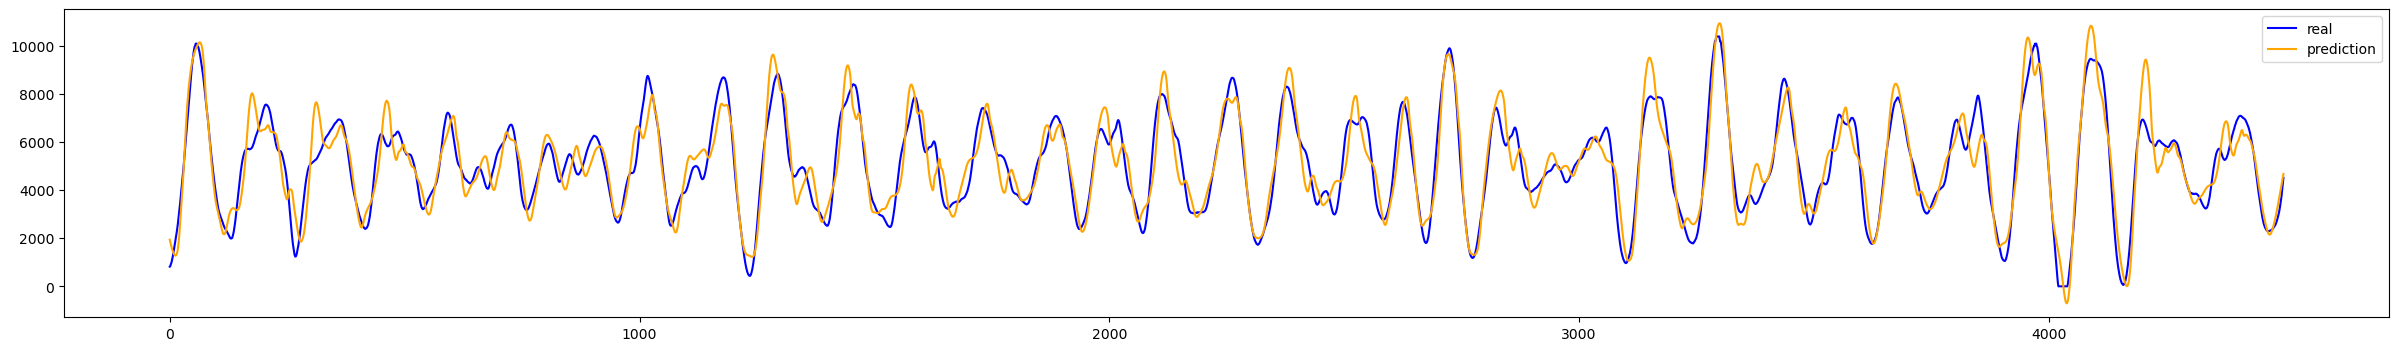

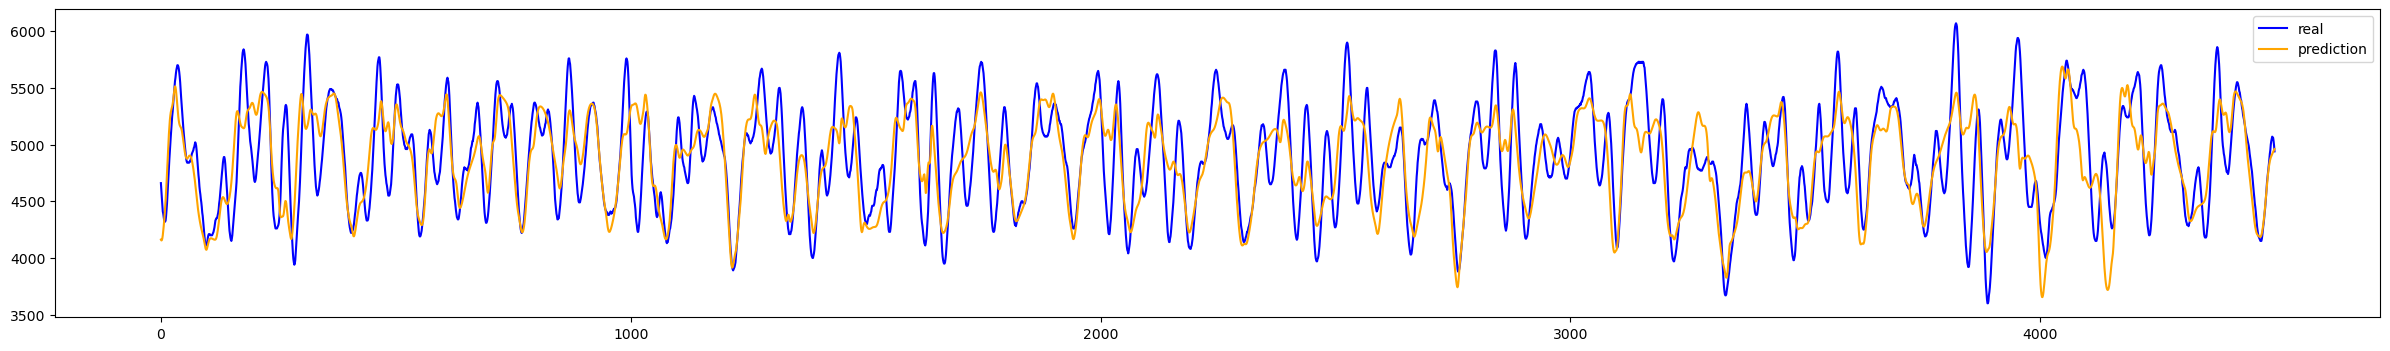

In [26]:
# 反归一化并绘制Force1真实值vs预测值曲线
fan_force150_real1,fan_force150_pre1 = FanGuiHua_force1(valid50_y_Force1,N_pre50_Y_Force1)
# 保存结果到CSV文件（真实值+预测值），分隔符为逗号
np.savetxt('force1500_步长10_LSTM.csv',np.hstack((fan_force150_real1,fan_force150_pre1)),delimiter=',')


fan_force250_real1,fan_force250_pre1 = FanGuiHua_force2(valid50_y_Force2,N_pre50_Y_Force2)

np.savetxt('force2500_步长10_LSTM.csv',np.hstack((fan_force250_real1,fan_force250_pre1)),delimiter=',')

6. 系泊力模型评估

In [27]:
RNSE(valid50_y_Force1,N_pre50_Y_Force1)
Acc(valid50_y_Force1,N_pre50_Y_Force1)


RNSE(valid50_y_Force2,N_pre50_Y_Force2)
Acc(valid50_y_Force2,N_pre50_Y_Force2)

RMSE(sklearn): 0.12314930043484784
Acc: 0.9675346767575278
RMSE(sklearn): 0.1471843562720374
Acc: 0.8810949184716608


#### 系泊缆力联合预测（输入500步长，输出20步长）

In [28]:
# 未来运动预测模型建立
train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2 = split_train_valid(heave50_x2,heave50_y2, 4500, 7500, 12000)
heave50_model2, heave50_history2, pre_heave50_Y2 = Model_LSTM(train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2 = split_train_valid(surge50_x2,surge50_y2, 4200, 7500, 12000)
surge50_model2, surge50_history2, pre_surge50_Y2 = Model_LSTM(train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2 = split_train_valid(pitch50_x2,pitch50_y2, 4500, 7500, 12000)
pitch50_model2, pitch50_history2, pre_pitch50_Y2 = Model_LSTM(train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Epoch 1/30


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


60/60 - 4s - loss: 0.1076 - val_loss: 0.0868 - 4s/epoch - 68ms/step
Epoch 2/30
60/60 - 3s - loss: 0.0562 - val_loss: 0.0558 - 3s/epoch - 51ms/step
Epoch 3/30
60/60 - 3s - loss: 0.0491 - val_loss: 0.0384 - 3s/epoch - 50ms/step
Epoch 4/30
60/60 - 3s - loss: 0.0381 - val_loss: 0.0363 - 3s/epoch - 53ms/step
Epoch 5/30
60/60 - 3s - loss: 0.0350 - val_loss: 0.0325 - 3s/epoch - 54ms/step
Epoch 6/30
60/60 - 3s - loss: 0.0327 - val_loss: 0.0292 - 3s/epoch - 54ms/step
Epoch 7/30
60/60 - 3s - loss: 0.0316 - val_loss: 0.0313 - 3s/epoch - 54ms/step
Epoch 8/30
60/60 - 3s - loss: 0.0303 - val_loss: 0.0285 - 3s/epoch - 53ms/step
Epoch 9/30
60/60 - 3s - loss: 0.0294 - val_loss: 0.0357 - 3s/epoch - 52ms/step
Epoch 10/30
60/60 - 3s - loss: 0.0319 - val_loss: 0.0275 - 3s/epoch - 51ms/step
Epoch 11/30
60/60 - 3s - loss: 0.0267 - val_loss: 0.0256 - 3s/epoch - 52ms/step
Epoch 12/30
60/60 - 3s - loss: 0.0267 - val_loss: 0.0348 - 3s/epoch - 53ms/step
Epoch 13/30
60/60 - 3s - loss: 0.0298 - val_loss: 0.0267 - 3

In [29]:
pretrain_heave50_Y2 = heave50_model2.predict(train_heave50_x2)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y2 = surge50_model2.predict(train_surge50_x2[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y2 = pitch50_model2.predict(train_pitch50_x2)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y2.shape)
print(pretrain_surge50_Y2.shape)
print(pretrain_pitch50_Y2.shape)

94/94 [==============================] - 1s 14ms/step
(3000, 1)
(3000, 1)
(3000, 1)


In [30]:
# 输入50步长输出2步长Force1
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3490:,:], 4, 519)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 500)
# print(force150_x2.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)


# 输入50步长输出2步长Force2
force250_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3490:,:], 4, 519)
force250_x2,force250_y2 = split_sequence(force250_scaled2, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [31]:
train_force150_x2, train_force150_y2, valid_force150_x2, valid_force150_y2 = split_train_valid(force150_x2,force150_y2, 4500, 7500, 12000)
train50_x2_Force1, valid50_x2_Force1 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force1, valid50_y2_Force1 = train_force150_y2, valid_force150_y2
N_model50_2_Force1, N_history50_2_Force1, N_pre50_train_Y2_Force1, N_pre50_Y2_Force1 = Model_NN(train50_x2_Force1, train50_y2_Force1, valid50_x2_Force1, valid50_y2_Force1, lr=0.01, epochs=1000, batch_size=256)


train_force250_x2, train_force250_y2, valid_force250_x2, valid_force250_y2 = split_train_valid(force250_x2,force250_y2, 4500, 7500, 12000)
train50_x2_Force2, valid50_x2_Force2 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force2, valid50_y2_Force2 = train_force250_y2, valid_force250_y2
N_model50_2_Force2, N_history50_2_Force2, N_pre50_train_Y2_Force2, N_pre50_Y2_Force2 = Model_NN(train50_x2_Force2, train50_y2_Force2, valid50_x2_Force2, valid50_y2_Force2,lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
12/12 - 0s - loss: 0.0422 - val_loss: 0.0324 - 314ms/epoch - 26ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0408 - val_loss: 0.0529 - 69ms/epoch - 6ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0337 - val_loss: 0.0254 - 62ms/epoch - 5ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0306 - val_loss: 0.0276 - 66ms/epoch - 5ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0277 - val_loss: 0.0264 - 71ms/epoch - 6ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0284 - val_loss: 0.0258 - 76ms/epoch - 6ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0270 - val_loss: 0.0261 - 72ms/epoch - 6ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0274 - val_loss: 0.0262 - 64ms/epoch - 5ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0274 - val_loss: 0.0255 - 55ms/epoch - 5ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0272 - val_loss: 0.0264 - 57ms/epoch - 5ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0274 - val_loss: 0.0255 - 56ms/epoch - 5ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0271 - val_loss: 0.0262 - 59ms/epoch - 5ms/step
Epoch 13/10

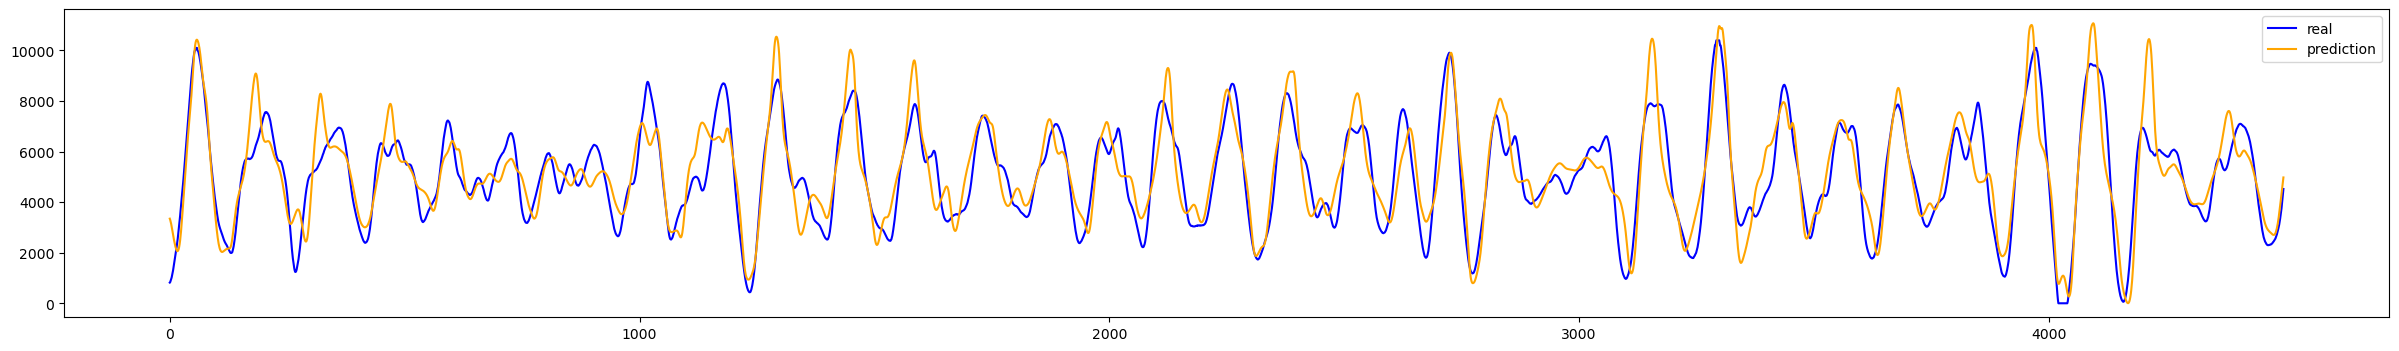

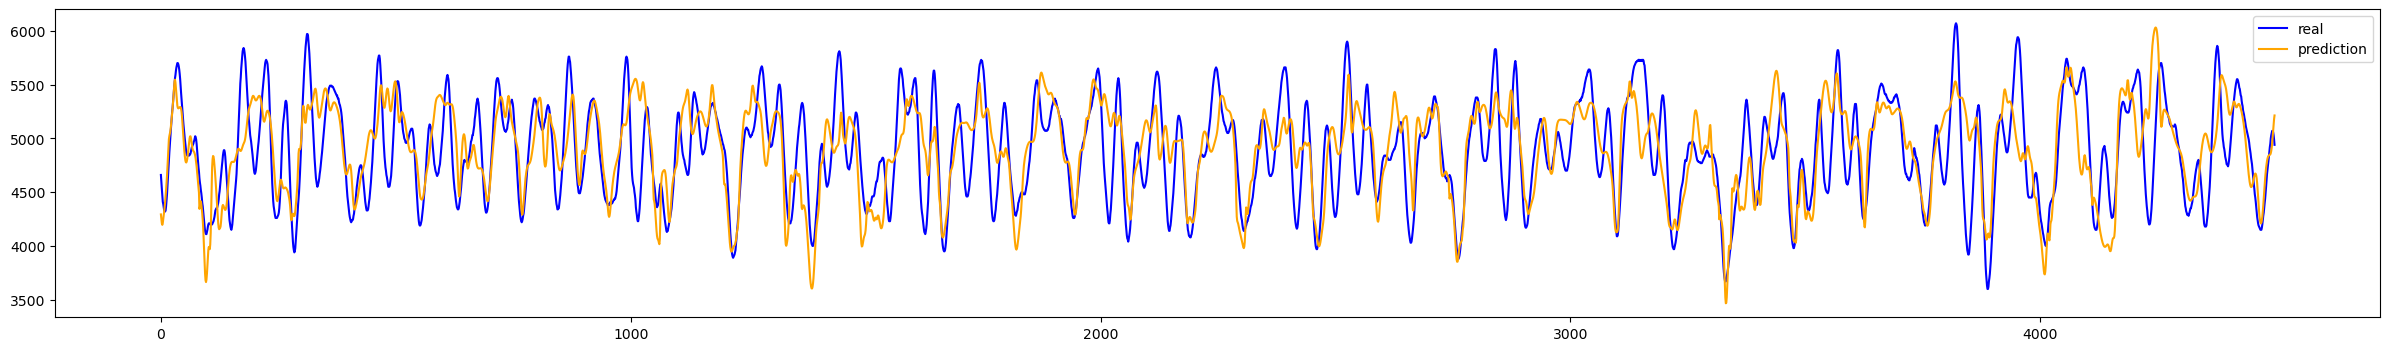

In [32]:
fan_force150_real2,fan_force150_pre2 = FanGuiHua_force1(valid50_y2_Force1,N_pre50_Y2_Force1)

np.savetxt('force1500_步长20_LSTM.csv',np.hstack((fan_force150_real2,fan_force150_pre2)),delimiter=',')


fan_force250_real2,fan_force250_pre2 = FanGuiHua_force2(valid50_y2_Force2,N_pre50_Y2_Force2)

np.savetxt('force2500_步长20_LSTM.csv',np.hstack((fan_force250_real2,fan_force250_pre2)),delimiter=',')

In [33]:
RNSE(valid50_y2_Force1,N_pre50_Y2_Force1)
Acc(valid50_y2_Force1,N_pre50_Y2_Force1)


RNSE(valid50_y2_Force2,N_pre50_Y2_Force2)
Acc(valid50_y2_Force2,N_pre50_Y2_Force2)

RMSE(sklearn): 0.1641100868081997
Acc: 0.9261790588903965
RMSE(sklearn): 0.16865757368603726
Acc: 0.8857711500130772


#### 系泊缆力联合预测（输入500步长，输出30步长）

In [34]:
# 未来运动预测模型建立
train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3 = split_train_valid(heave50_x3,heave50_y3, 4500, 7500, 12000)
heave50_model3, heave50_history3, pre_heave50_Y3 = Model_LSTM(train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3 = split_train_valid(surge50_x3,surge50_y3, 4200, 7500, 12000)
surge50_model3, surge50_history3, pre_surge50_Y3 = Model_LSTM(train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3 = split_train_valid(pitch50_x3,pitch50_y3, 4500, 7500, 12000)
pitch50_model3, pitch50_history3, pre_pitch50_Y3 = Model_LSTM(train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Epoch 1/30


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


60/60 - 4s - loss: 0.0748 - val_loss: 0.0304 - 4s/epoch - 68ms/step
Epoch 2/30
60/60 - 3s - loss: 0.0356 - val_loss: 0.0604 - 3s/epoch - 53ms/step
Epoch 3/30
60/60 - 3s - loss: 0.0434 - val_loss: 0.0456 - 3s/epoch - 53ms/step
Epoch 4/30
60/60 - 3s - loss: 0.0401 - val_loss: 0.0349 - 3s/epoch - 53ms/step
Epoch 5/30
60/60 - 3s - loss: 0.0352 - val_loss: 0.0371 - 3s/epoch - 54ms/step
Epoch 6/30
60/60 - 3s - loss: 0.0355 - val_loss: 0.0395 - 3s/epoch - 53ms/step
Epoch 7/30
60/60 - 3s - loss: 0.0374 - val_loss: 0.0432 - 3s/epoch - 53ms/step
Epoch 8/30
60/60 - 3s - loss: 0.0399 - val_loss: 0.0281 - 3s/epoch - 53ms/step
Epoch 9/30
60/60 - 3s - loss: 0.0326 - val_loss: 0.0368 - 3s/epoch - 51ms/step
Epoch 10/30
60/60 - 3s - loss: 0.0355 - val_loss: 0.0317 - 3s/epoch - 53ms/step
Epoch 11/30
60/60 - 3s - loss: 0.0332 - val_loss: 0.0389 - 3s/epoch - 53ms/step
Epoch 12/30
60/60 - 3s - loss: 0.0365 - val_loss: 0.0296 - 3s/epoch - 53ms/step
Epoch 13/30
60/60 - 3s - loss: 0.0316 - val_loss: 0.0370 - 3

In [35]:
pretrain_heave50_Y3 = heave50_model3.predict(train_heave50_x3)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y3 = surge50_model3.predict(train_surge50_x3[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y3 = pitch50_model3.predict(train_pitch50_x3)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y3.shape)
print(pretrain_surge50_Y3.shape)
print(pretrain_pitch50_Y3.shape)

94/94 [==============================] - 1s 15ms/step
(3000, 1)
(3000, 1)
(3000, 1)


In [36]:
# 输入50步长输出3步长Force1
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3480:,:], 4, 529)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)


# 输入50步长输出3步长Force2
force250_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3480:,:], 4, 529)
force250_x3,force250_y3 = split_sequence(force250_scaled3, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [37]:
train_force150_x3, train_force150_y3, valid_force150_x3, valid_force150_y3 = split_train_valid(force150_x3,force150_y3, 4500, 7500, 12000)
train50_x3_Force1, valid50_x3_Force1 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force1, valid50_y3_Force1 = train_force150_y3, valid_force150_y3
N_model50_3_Force1, N_history50_3_Force1, N_pre50_train_Y3_Force1, N_pre50_Y3_Force1 = Model_NN(train50_x3_Force1, train50_y3_Force1, valid50_x3_Force1, valid50_y3_Force1, lr=0.01, epochs=1000, batch_size=256)


train_force250_x3, train_force250_y3, valid_force250_x3, valid_force250_y3 = split_train_valid(force250_x3,force250_y3, 4500, 7500, 12000)
train50_x3_Force2, valid50_x3_Force2 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force2, valid50_y3_Force2 = train_force250_y3, valid_force250_y3
N_model50_3_Force2, N_history50_3_Force2, N_pre50_train_Y3_Force2, N_pre50_Y3_Force2 = Model_NN(train50_x3_Force2, train50_y3_Force2, valid50_x3_Force2, valid50_y3_Force2, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
12/12 - 0s - loss: 0.0467 - val_loss: 0.0352 - 318ms/epoch - 26ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0416 - val_loss: 0.0473 - 57ms/epoch - 5ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0335 - val_loss: 0.0296 - 54ms/epoch - 4ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0342 - val_loss: 0.0345 - 54ms/epoch - 5ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0298 - val_loss: 0.0283 - 54ms/epoch - 5ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0306 - val_loss: 0.0320 - 60ms/epoch - 5ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0297 - val_loss: 0.0276 - 57ms/epoch - 5ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0297 - val_loss: 0.0305 - 61ms/epoch - 5ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0287 - val_loss: 0.0273 - 63ms/epoch - 5ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0290 - val_loss: 0.0299 - 55ms/epoch - 5ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0282 - val_loss: 0.0274 - 55ms/epoch - 5ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0286 - val_loss: 0.0295 - 66ms/epoch - 5ms/step
Epoch 13/10

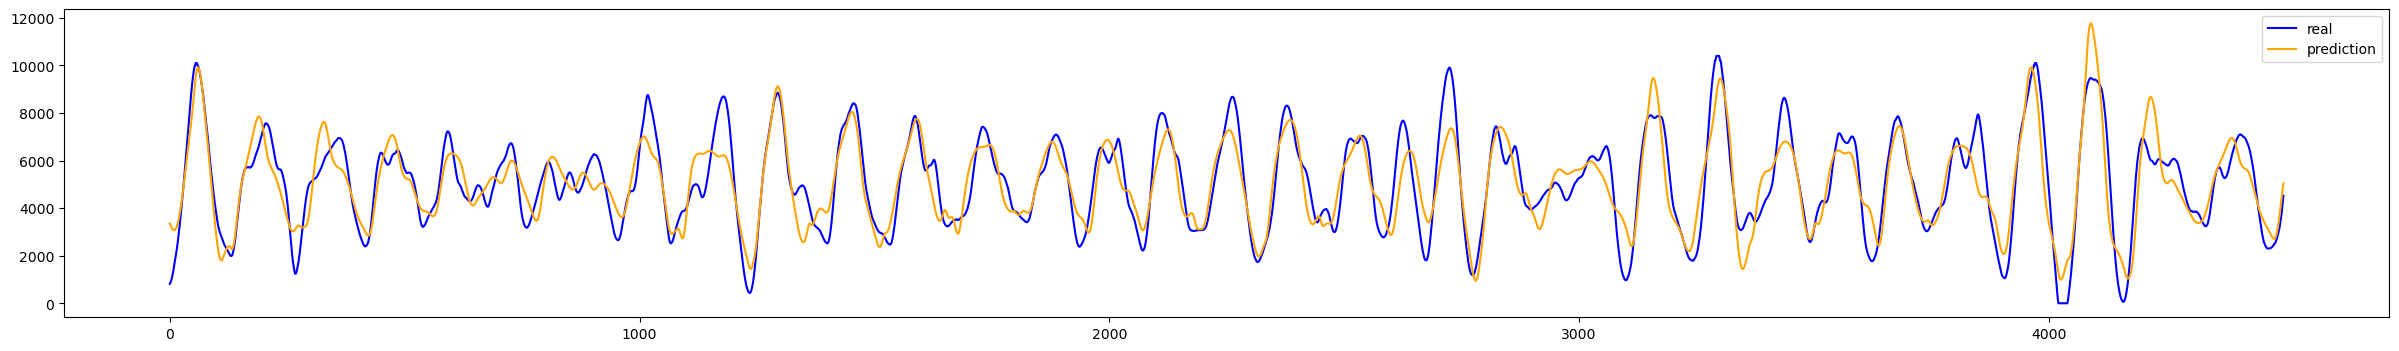

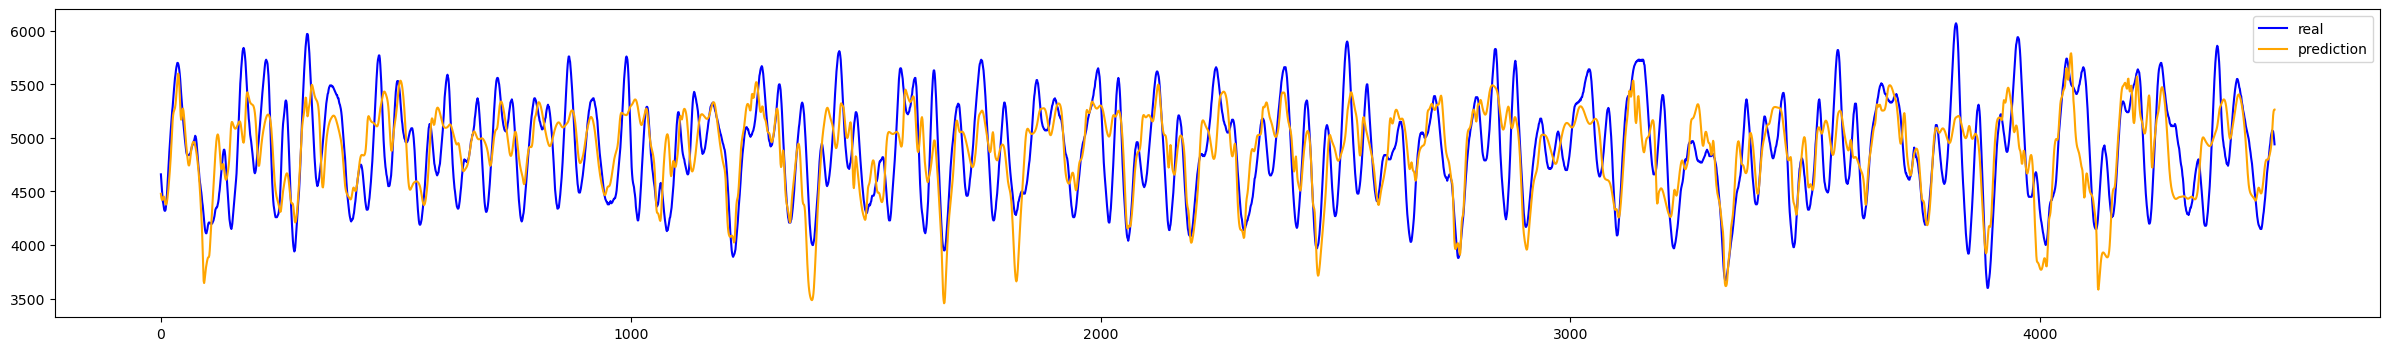

In [38]:
fan_force150_real3,fan_force150_pre3 = FanGuiHua_force1(valid50_y3_Force1,N_pre50_Y3_Force1)

np.savetxt('force1500_步长30_LSTM.csv',np.hstack((fan_force150_real3,fan_force150_pre3)),delimiter=',')


fan_force250_real3,fan_force250_pre3 = FanGuiHua_force2(valid50_y3_Force2,N_pre50_Y3_Force2)

np.savetxt('force2500_步长30_LSTM.csv',np.hstack((fan_force250_real3,fan_force250_pre3)),delimiter=',')

In [39]:
RNSE(valid50_y3_Force1,N_pre50_Y3_Force1)
Acc(valid50_y3_Force1,N_pre50_Y3_Force1)


RNSE(valid50_y3_Force2,N_pre50_Y3_Force2)
Acc(valid50_y3_Force2,N_pre50_Y3_Force2)

RMSE(sklearn): 0.15671585220813244
Acc: 0.8705314630558944
RMSE(sklearn): 0.1665647164260642
Acc: 0.8145996116389203


#### 系泊缆力联合预测（输入500步长，输出40步长）

In [40]:
# 未来运动预测模型建立
train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4 = split_train_valid(heave50_x4,heave50_y4, 4500, 7500, 12000)
heave50_model4, heave50_history4, pre_heave50_Y4 = Model_LSTM(train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4 = split_train_valid(surge50_x4,surge50_y4, 4200, 7500, 12000)
surge50_model4, surge50_history4, pre_surge50_Y4 = Model_LSTM(train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4 = split_train_valid(pitch50_x4,pitch50_y4, 4500, 7500, 12000)
pitch50_model4, pitch50_history4, pre_pitch50_Y4 = Model_LSTM(train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Epoch 1/30


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


60/60 - 4s - loss: 0.0811 - val_loss: 0.0399 - 4s/epoch - 59ms/step
Epoch 2/30
60/60 - 3s - loss: 0.0402 - val_loss: 0.0419 - 3s/epoch - 45ms/step
Epoch 3/30
60/60 - 3s - loss: 0.0398 - val_loss: 0.0401 - 3s/epoch - 43ms/step
Epoch 4/30
60/60 - 3s - loss: 0.0393 - val_loss: 0.0364 - 3s/epoch - 43ms/step
Epoch 5/30
60/60 - 3s - loss: 0.0370 - val_loss: 0.0402 - 3s/epoch - 51ms/step
Epoch 6/30
60/60 - 3s - loss: 0.0388 - val_loss: 0.0323 - 3s/epoch - 52ms/step
Epoch 7/30
60/60 - 3s - loss: 0.0346 - val_loss: 0.0436 - 3s/epoch - 52ms/step
Epoch 8/30
60/60 - 3s - loss: 0.0410 - val_loss: 0.0357 - 3s/epoch - 52ms/step
Epoch 9/30
60/60 - 3s - loss: 0.0333 - val_loss: 0.0352 - 3s/epoch - 51ms/step
Epoch 10/30
60/60 - 3s - loss: 0.0356 - val_loss: 0.0476 - 3s/epoch - 51ms/step
Epoch 11/30
60/60 - 3s - loss: 0.0422 - val_loss: 0.0307 - 3s/epoch - 50ms/step
Epoch 12/30
60/60 - 3s - loss: 0.0325 - val_loss: 0.0333 - 3s/epoch - 51ms/step
Epoch 13/30
60/60 - 3s - loss: 0.0320 - val_loss: 0.0316 - 3

In [41]:
pretrain_heave50_Y4 = heave50_model4.predict(train_heave50_x4)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y4 = surge50_model4.predict(train_surge50_x4[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y4 = pitch50_model4.predict(train_pitch50_x4)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y4.shape)
print(pretrain_surge50_Y4.shape)
print(pretrain_pitch50_Y4.shape)

94/94 [==============================] - 1s 15ms/step
(3000, 1)
(3000, 1)
(3000, 1)


In [42]:
# 输入50步长输出4步长Force1
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3470:,:], 4, 539)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)


# 输入50步长输出4步长Force2
force250_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3470:,:], 4, 539)
force250_x4,force250_y4 = split_sequence(force250_scaled4, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [43]:
train_force150_x4, train_force150_y4, valid_force150_x4, valid_force150_y4 = split_train_valid(force150_x4,force150_y4, 4500, 7500, 12000)
train50_x4_Force1, valid50_x4_Force1 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force1, valid50_y4_Force1 = train_force150_y4, valid_force150_y4
N_model50_4_Force1, N_history50_4_Force1, N_pre50_train_Y4_Force1, N_pre50_Y4_Force1 = Model_NN(train50_x4_Force1, train50_y4_Force1, valid50_x4_Force1, valid50_y4_Force1, lr=0.01, epochs=1000, batch_size=256)


train_force250_x4, train_force250_y4, valid_force250_x4, valid_force250_y4 = split_train_valid(force250_x4,force250_y4, 4500, 7500, 12000)
train50_x4_Force2, valid50_x4_Force2 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force2, valid50_y4_Force2 = train_force250_y4, valid_force250_y4
N_model50_4_Force2, N_history50_4_Force2, N_pre50_train_Y4_Force2, N_pre50_Y4_Force2 = Model_NN(train50_x4_Force2, train50_y4_Force2, valid50_x4_Force2, valid50_y4_Force2, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
12/12 - 0s - loss: 0.0431 - val_loss: 0.0550 - 315ms/epoch - 26ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0393 - val_loss: 0.0483 - 57ms/epoch - 5ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0339 - val_loss: 0.0305 - 58ms/epoch - 5ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0331 - val_loss: 0.0309 - 57ms/epoch - 5ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0295 - val_loss: 0.0273 - 59ms/epoch - 5ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0299 - val_loss: 0.0287 - 59ms/epoch - 5ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0278 - val_loss: 0.0268 - 55ms/epoch - 5ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0280 - val_loss: 0.0274 - 54ms/epoch - 4ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0268 - val_loss: 0.0269 - 52ms/epoch - 4ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0270 - val_loss: 0.0273 - 56ms/epoch - 5ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0266 - val_loss: 0.0270 - 61ms/epoch - 5ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0267 - val_loss: 0.0273 - 59ms/epoch - 5ms/step
Epoch 13/10

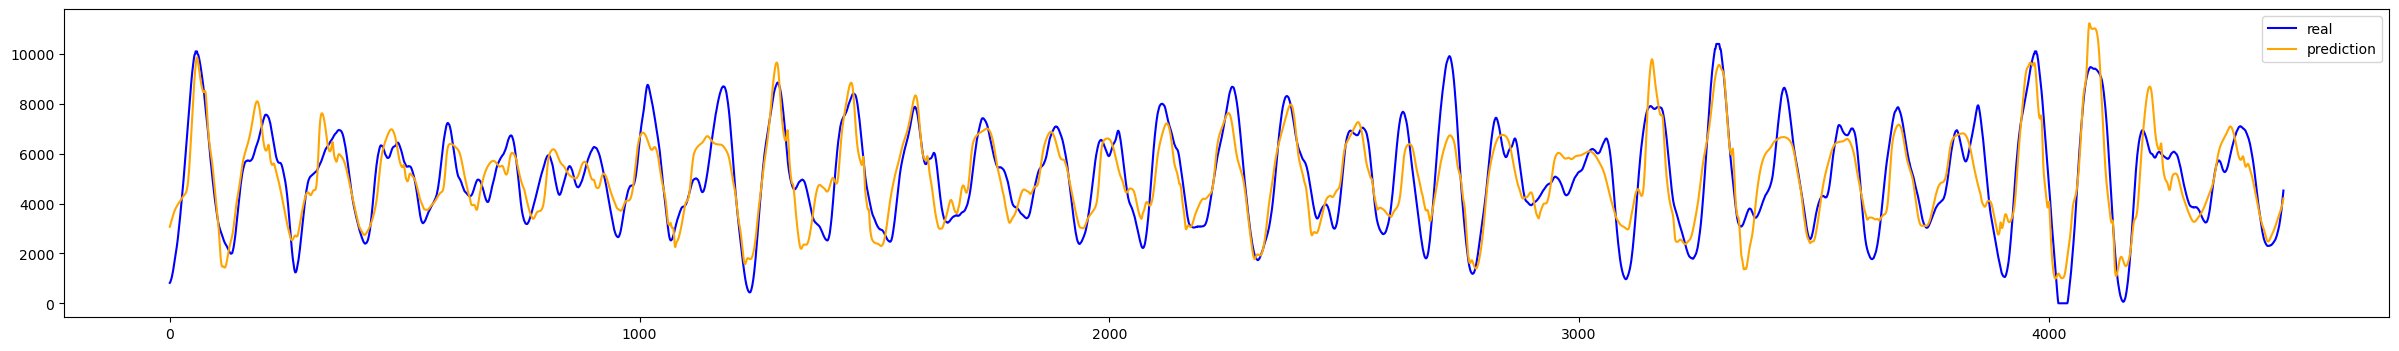

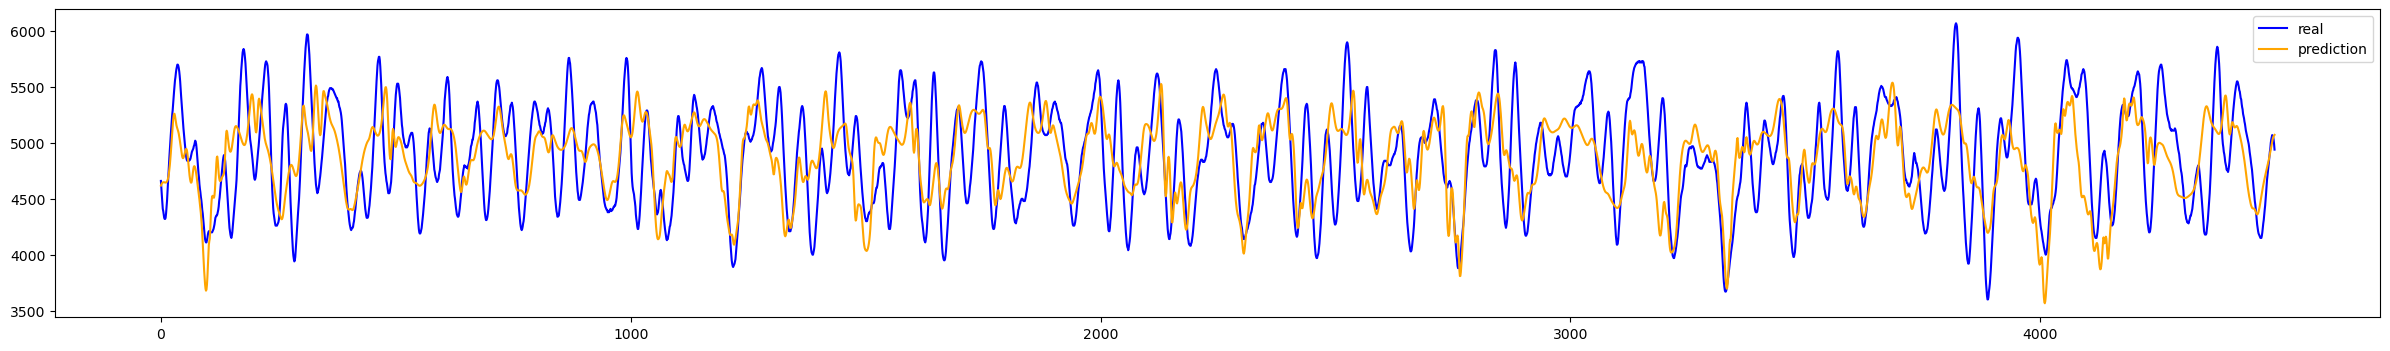

In [44]:
fan_force150_real4,fan_force150_pre4 = FanGuiHua_force1(valid50_y4_Force1,N_pre50_Y4_Force1)

np.savetxt('force1500_步长40_LSTM.csv',np.hstack((fan_force150_real4,fan_force150_pre4)),delimiter=',')


fan_force250_real4,fan_force250_pre4 = FanGuiHua_force2(valid50_y4_Force2,N_pre50_Y4_Force2)

np.savetxt('force2500_步长40_LSTM.csv',np.hstack((fan_force250_real4,fan_force250_pre4)),delimiter=',')

In [45]:
RNSE(valid50_y4_Force1,N_pre50_Y4_Force1)
Acc(valid50_y4_Force1,N_pre50_Y4_Force1)


RNSE(valid50_y4_Force2,N_pre50_Y4_Force2)
Acc(valid50_y4_Force2,N_pre50_Y4_Force2)

RMSE(sklearn): 0.17281797160231835
Acc: 0.8624768712031166
RMSE(sklearn): 0.18054868865310686
Acc: 0.7376731637305849
